# **Auditoría de Datos Electorales de Colombia – 31 de Mayo de 2026**

- Autor: Kevin Medina Acosta
- kevinacostadavidmedina@gmail.com

### Aviso de Exención de Responsabilidad y Alcance del Proyecto

Este proyecto se desarrolla con fines estrictamente académicos, profesionales y de demostración de competencias en ingeniería de sistemas y analítica
de datos. No promueve, incita ni respalda posturas políticas, ideológicas ni acusaciones de ninguna índole. El análisis se fundamenta exclusivamente 
en datos de carácter público, compartidos el 2 de junio de 2026 a través de la cuenta oficial de Facebook del entonces presidente Gustavo Petro, 
con el objetivo de auditar la consistencia técnica de las estructuras de datos suministradas.

### Introducción y Metodología
 
Este análisis sigue el ciclo de vida de los datos propuesto en el programa de Certificación en Analítica de Datos de Google. Para ello, se emplea un
conjunto de datos de carácter público relacionado con los resultados electorales del 31 de mayo del año 2026, sobre el cual **se desarrollan las distintas fases del proceso analítico (preguntar, preparar, procesar, analizar, compartir/visualizar, actuar).**

La estructura del trabajo se organiza de forma secuencial y reproducible, permitiendo documentar cada etapa del análisis y garantizar la trazabilidad 
metodológica de los resultados obtenidos.

### Planteamiento del Problema
 
El análisis se centra en verificar la consistencia de los datos frente a la afirmación publicada por el entonces presidente Gustavo Petro el 2 de junio de 2026 en su cuenta oficial de Facebook:

> *"Aquí entrego las 5.300 mesas atípicas en donde hay muchos más sufragantes de los que son físicamente posibles. El escrutinio sobre estas mesas debe hacerse no solo contando de nuevo los votos, sino comparando los listados de votantes con el E-11 y con el censo electoral oficial..."*

A partir de esta declaración pública, el problema técnico a resolver consiste en auditar el dataset para responder a dos situaciones específicas:
- **A. Inconsistencia física:** Validar si existen mesas donde el número de votantes reales supera el límite máximo permitido por el censo oficial (*Potencial*).
- **B. Variabilidad de datos:** Medir las discrepancias numéricas entre el conteo rápido inicial (*PRE*) y el escrutinio final (*ESC*), evaluando si la falta de controles físicos (como las firmas de los jurados) influye en la calidad de la información.

## **Fase 1: Preguntar**
En esta fase se definen las preguntas de investigación que orientarán el proceso de auditoría y análisis de los datos electorales.

#### Situación A: Inconsistencia Física
1. **¿Qué porcentaje de las mesas analizadas presentaron un total de sufragantes superior al potencial de votantes permitido?**
   > *Explicación:* Busca detectar registros físicamente imposibles, donde el número de votos reportados supera la cantidad máxima de personas habilitadas para votar en esa mesa.
#### Situación B: Variabilidad de Datos
2. **¿Cuáles son los municipios con las mayores diferencias entre los resultados preliminares (PRE) y los resultados oficiales (ESC)?**
   > *Explicación:* Busca comparar los votos reportados en el preconteo con los votos del escrutinio oficial para identificar los municipios donde se produjeron los mayores cambios numéricos entre ambos procesos.
3. **¿Cuántas mesas presentan más de un indicador de alerta dentro de los datos analizados?**
   > *Explicación:* Busca identificar la coincidencia de diferentes indicadores de alerta, como concentraciones inusuales de votos y ausencia de firmas de los jurados de votación, para detectar registros que podrían requerir una revisión más detallada.

## **Fase 2: Preparar**

En esta fase se documenta el origen del conjunto de datos y se realiza una inspección inicial de las variables para comprender su estructura y limitaciones antes de cualquier transformación.

#### - Fuente de Datos
El conjunto de datos analizado corresponde a los registros electorales de la jornada del 31 de mayo, publicados de forma abierta el 2 de junio de 2026, por el entonces presidente Gustavo Petro en su cuenta oficial de Facebook. El archivo se encuentra almacenado de manera local en la ruta del proyecto (`data/raw/EVIDENCIAS MESAS.xlsx`) en su estado primario e inalterado.

#### - Carga y Exploración

In [1]:
import pandas as pd

# Mostrar todas las columnas y evitar cortes en la visualización de DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# 1. Cargar el archivo original
ruta_raw = "../data/raw/EVIDENCIAS MESAS.xlsx"
df = pd.read_excel(ruta_raw)

# 2. Explorar la estructura general
print("--- DIMENSIONES DEL DATASET ---")
print(f"Total de registros/filas (incluye filas vacías) : {df.shape[0]}")
print(f"Total de variables (Columnas): {df.shape[1]}\n")

print("--- DIAGNÓSTICO DE METADATOS (INFO) ---")
df.info()

--- DIMENSIONES DEL DATASET ---
Total de registros/filas (incluye filas vacías) : 5637
Total de variables (Columnas): 40

--- DIAGNÓSTICO DE METADATOS (INFO) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5637 entries, 0 to 5636
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   DEPARTAMENTO                  5556 non-null   object 
 1   MUNICIPIO                     5555 non-null   object 
 2   ZZ                            5555 non-null   float64
 3   PP                            5555 non-null   object 
 4   PUESTO                        5555 non-null   object 
 5   MESA                          5555 non-null   float64
 6   COD CAN                       5555 non-null   float64
 7   CANDIDATO                     5555 non-null   object 
 8   POTENCIAL                     5555 non-null   float64
 9   % Partic. Mesa PRE            5555 non-null   float64
 10  Votos Mesa PRE    

In [2]:
# 3. Visualización de la muestra inicial (primeros 5 registros)
df.head()

,DEPARTAMENTO,MUNICIPIO,ZZ,PP,PUESTO,MESA,COD CAN,CANDIDATO,POTENCIAL,% Partic. Mesa PRE,Votos Mesa PRE,Votos Mesa ESC,Votos Cand. PRE,Votos Cand. ESC,Dif. Cand. Neta,% Cand. Mesa PRE,% Cand. Mesa ESC,% Cand. Mun PRE,% Cand. Mun ESC,Dif. % Mesa-Mun PRE,Dif. % Mesa-Mun ESC,Var. Súbita PRE,Var. Súbita ESC,Concent. Cand. PRE,Concent. Cand. ESC,Diferencias Mesa (-),Diferencias Mesa (+),Dif. Mesa Neta,En términos,Estado del sobre,Excluida,Firmas Jurados,Recontada Comisión,Recontada Jurados,Sufragantes E11 según E14,Sufragantes según E11,Tacahaduras y/o Enmendaduras,Total Votos E14,Votos Urna,Votos Incinerados
0,88 CONSULADOS,360-ESTADOS UNIDOS,35.0,81,LUNES LOS ANGELES - CONSULADO,1.0,4.0,ABELARDO DE LA ESPRIELLA,9999.0,0.0942,942.0,NaN,694.0,NaN,NaN,0.7367,NaN,0.721,NaN,NaN,NaN,0. Mínima,0. Mínima,2. Alta,0. Baja,-942.0,0.0,-942.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,88 CONSULADOS,360-ESTADOS UNIDOS,59.0,81,LUNES ORLANDO - CONSULADO,3.0,4.0,ABELARDO DE LA ESPRIELLA,9999.0,0.0615,615.0,NaN,564.0,NaN,NaN,0.9171,NaN,0.721,NaN,NaN,NaN,3. Alta,0. Mínima,3. Muy Alta,0. Baja,-615.0,0.0,-615.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,88 CONSULADOS,360-ESTADOS UNIDOS,40.0,81,LUNES MIAMI - CONSULADO,15.0,4.0,ABELARDO DE LA ESPRIELLA,9999.0,0.0573,573.0,NaN,526.0,NaN,NaN,0.9180,NaN,0.721,NaN,NaN,NaN,3. Alta,0. Mínima,3. Muy Alta,0. Baja,-573.0,0.0,-573.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,88 CONSULADOS,360-ESTADOS UNIDOS,59.0,81,LUNES ORLANDO - CONSULADO,4.0,4.0,ABELARDO DE LA ESPRIELLA,9999.0,0.0562,562.0,NaN,503.0,NaN,NaN,0.8950,NaN,0.721,NaN,NaN,NaN,3. Alta,0. Mínima,3. Muy Alta,0. Baja,-562.0,0.0,-562.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,88 CONSULADOS,360-ESTADOS UNIDOS,59.0,81,LUNES ORLANDO - CONSULADO,2.0,4.0,ABELARDO DE LA ESPRIELLA,9999.0,0.0548,548.0,NaN,497.0,NaN,NaN,0.9069,NaN,0.721,NaN,NaN,NaN,3. Alta,0. Mínima,3. Muy Alta,0. Baja,-548.0,0.0,-548.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# 4. Diagnóstico explícito de datos faltantes (Vacíos/NaN)

tabla_calidad = pd.DataFrame({
    'Variable': df.columns,
    'Valores_Vacios': df.isnull().sum().values,
    'Porcentaje_Vacios': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Tipo_Dato': df.dtypes.values
})

print(tabla_calidad)

                        Variable  Valores_Vacios  Porcentaje_Vacios Tipo_Dato
0                   DEPARTAMENTO              81               1.44    object
1                      MUNICIPIO              82               1.45    object
2                             ZZ              82               1.45   float64
3                             PP              82               1.45    object
4                         PUESTO              82               1.45    object
5                           MESA              82               1.45   float64
6                        COD CAN              82               1.45   float64
7                      CANDIDATO              82               1.45    object
8                      POTENCIAL              82               1.45   float64
9             % Partic. Mesa PRE              82               1.45   float64
10                Votos Mesa PRE              82               1.45   float64
11                Votos Mesa ESC             900              15

#### - Descripción de Variables Críticas

A partir de la inspección inicial, se identifican las variables esenciales que se usarán en las situaciones (A y B) de control de la auditoría:

| Variable | Tipo de Dato (inferido usando Pandas-Python) | Descripción Técnica |
| :--- | :--- | :--- |
| **`POTENCIAL`** | `float64` | Censo electoral de la mesa (Cantidad máxima de ciudadanos habilitados para votar). |
| **`Sufragantes según E11`** | `float64` | Volumen real de ciudadanos que asistieron a votar y firmaron el formulario físico. |
| **`Concent. Cand. ESC`** | `object` (Texto) | Alerta categórica sobre niveles inusuales de acumulación de votos hacia un candidato. |
| **`Firmas Jurados`** | `float64` | Cantidad de firmas de control registradas por los jurados en el acta de mesa. |
| **`Votos Mesa PRE`** | `float64` | Resultados numéricos transmitidos durante el preconteo rápido e informativo (es el conteo rápido y preliminar realizado en las mesas la misma tarde de la elección).|
| **`Votos Mesa ESC`** | `float64` | Resultados numéricos definitivos consolidados durante el escrutinio oficial (es el único conteo oficial, definitivo y con validez jurídica).|

> **Nota de Aseguramiento de Calidad:** Durante esta fase no se realizan eliminaciones, correcciones, ni transformaciones de formato. El conjunto de datos se mantiene en su estado crudo original. Todo el proceso de reestructuración se delega estrictamente a la **Fase 3: Procesar**.

## **Fase 3: Procesar**

En esta fase se implementa el proceso de limpieza y transformación de los datos con el objetivo de garantizar su calidad y consistencia para el análisis posterior. A partir del diagnóstico realizado en la etapa de preparación, se identificaron valores ausentes (NaN) y tipos de datos inconsistentes derivados de registros vacíos.

Con el fin de garantizar la calidad, consistencia y preparación del conjunto de datos para su análisis, es necesario aplicar lo siguiente:
1. **Tratamiento de Valores Ausentes:** Sustitución de valores nulos (`NaN`) por `0` en las variables de conteo físico y votos, asumiendo la ausencia de registros en dichas mesas. Por otra parte, para la variable categórica **Concent. Cand. ESC** se imputó (agregó) la categoría "Sin Registro".
2. **Conversión de tipos de datos:** Conversión de variables de tipo flotante (`float64`) a tipo entero (`int64`), debido a que representan cantidades discretas (enteras) de ciudadanos, firmas y votos.
3. **Estandarización de datos categóricos:** Se eliminaron espacios en blanco innecesarios en los registros de texto para evitar inconsistencias.
4. **Preservación y validación de datos:** Se trabajó sobre una copia del conjunto de datos original (df_clean) y se verificó la ausencia de valores nulos residuales junto con la correcta asignación de los tipos de datos.

In [4]:
# 1. Preservar los datos originales
df_clean = df.copy()

# 2. Definición de variables que requieren conversión (originalmente detectadas como float64 para pasar a int64)
#VARIABLES NUMÉRICAS DISCRETAS
columnas_a_procesar = [
    'POTENCIAL',
    'Sufragantes según E11',
    'Firmas Jurados',
    'Votos Mesa PRE',
    'Votos Mesa ESC'
]

# 3. Tratamiento de Valores Ausentes (imputación por valor constante = 0)
# Regla de negocio: espacios vacíos equivalen a la ausencia física de registros/votos en la mesa.
for col in columnas_a_procesar:
    if col in df_clean.columns:
        # Contar nulos antes de la transformación para auditoría interna
        nulos_antes = df_clean[col].isnull().sum()
        
        # Aplicar imputación fija
        df_clean[col] = df_clean[col].fillna(0)
        
# 4. Conversión de Tipos de Datos (float64 a int64)
# Justificación: representan variables cuantitativas discretas (personas, actas, votos).
        df_clean[col] = df_clean[col].astype('int64')
        print(f"Variable '{col}': {nulos_antes} nulos corregidos. Tipo actualizado a int64.")
        

#5 Definición de variable que requiere imputar los valores vacíos con una cadena de texto. 
col_categorica = 'Concent. Cand. ESC'
if col_categorica in df_clean.columns:
    nulos_cat_antes = df_clean[col_categorica].isnull().sum()
    
    # 5.1. Imputar nulos con una etiqueta de control neutral
    df_clean[col_categorica] = df_clean[col_categorica].fillna("Sin Registro")
    # 5.2. Limpieza de strings (eliminar espacios en blanco invisibles al inicio/final)
    df_clean[col_categorica] = df_clean[col_categorica].astype(str).str.strip()
    
    print(f"Variable Categórica '{col_categorica}': {nulos_cat_antes} nulos imputados como 'Sin Registro'. Tipo: object.")


# VERIFICACIÓN INTERNA DEL DATASET PROCESADO (df_clean)
print("\n-----COMPROBACIÓN DE METADATOS EN EL NUEVO DATASET-----")
df_clean[columnas_a_procesar + [col_categorica]].info()


print("\n-----VERIFICAR CORRECCIÓN (DETERMINAR SI QUEDAN DATOS VACÍOS O NO)-----")
resumen_nulos = (
    df_clean[columnas_a_procesar + [col_categorica]]
    .isnull()
    .sum()
    .reset_index()
)

resumen_nulos.columns = ['Variable', 'Cantidad_Nulos']

print(resumen_nulos)
print("\nLOS DATOS FUERON PROCESADOS CON ÉXITO. ESTO SIGNIFICA QUE, YA ES POSIBLE REALIZAR LA SIGUIENTE FASE (ANALIZAR).")



#Exportar el dataset limpio a la carpeta de datos procesados
from pathlib import Path

# - Definir la ruta usando Path (maneja automáticamente los espacios)
ruta_proyecto = Path(r"C:\Users\Kevin Medina\auditoria-electoral-31-mayo-2026")
carpeta_procesada = ruta_proyecto / "data" / "processed"

# - Crear de forma obligatoria toda la estructura de carpetas si no existe en el disco
carpeta_procesada.mkdir(parents=True, exist_ok=True)

# - Definir las rutas de los archivos finales
ruta_csv = carpeta_procesada / "dataset_limpio.csv"
ruta_excel = carpeta_procesada / "dataset_limpio.xlsx"

# - Exportar el DataFrame limpio en ambos formatos
df_clean.to_csv(ruta_csv, index=False)
df_clean.to_excel(ruta_excel, index=False)


print(f"\n¡ARCHIVO GUARDADO CON ÉXITO! EL DATASET LIMPIO ESTÁ EN data/processed")

Variable 'POTENCIAL': 82 nulos corregidos. Tipo actualizado a int64.
Variable 'Sufragantes según E11': 898 nulos corregidos. Tipo actualizado a int64.
Variable 'Firmas Jurados': 898 nulos corregidos. Tipo actualizado a int64.
Variable 'Votos Mesa PRE': 82 nulos corregidos. Tipo actualizado a int64.
Variable 'Votos Mesa ESC': 900 nulos corregidos. Tipo actualizado a int64.
Variable Categórica 'Concent. Cand. ESC': 82 nulos imputados como 'Sin Registro'. Tipo: object.

-----COMPROBACIÓN DE METADATOS EN EL NUEVO DATASET-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5637 entries, 0 to 5636
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   POTENCIAL              5637 non-null   int64 
 1   Sufragantes según E11  5637 non-null   int64 
 2   Firmas Jurados         5637 non-null   int64 
 3   Votos Mesa PRE         5637 non-null   int64 
 4   Votos Mesa ESC         5637 non-null   int64 
 5   Conc

## **Fase 4: Analizar**

En esta fase se ejecutan las operaciones lógicas, filtros y agrupamientos aritméticos sobre el dataset purificado (`df_clean`) para resolver las situaciones de la auditoría (A: Inconsistencia Física y B: Variabilidad de Datos).

#### **Situación A: Inconsistencia Física**
En este caso, se evalúa el cumplimiento de la restricción física del sistema: el total de ciudadanos que ejercieron su derecho al voto en una mesa (*Sufragantes según E11*) no puede, bajo ninguna circunstancia, superar la capacidad máxima de ciudadanos habilitados en esa misma mesa (*POTENCIAL*).

In [5]:
# 1. Aplicar filtro lógico para aislar las mesas con inconsistencia física
mesas_inconsistentes = df_clean[df_clean['Sufragantes según E11'] > df_clean['POTENCIAL']]

# 2. Calcular métricas porcentuales (Camuflando conteos absolutos de mesas)
total_mesas_analizadas = len(df_clean)
cantidad_inconsistentes = len(mesas_inconsistentes)
porcentaje_inconsistentes = (cantidad_inconsistentes / total_mesas_analizadas) * 100

print("-----RESULTADOS SITUACIÓN A: INCONSISTENCIA FÍSICA-----\nNOTA: Sufragantes es lo mismo que votantes. Potencial es la cantidad de votantes habilitados por mesa.\n")
print(f"Porcentaje de afectación estructural en el dataset: {porcentaje_inconsistentes:.4f}%")

# 3. Mostrar el top de registros anómalos si existen para su auditoría manual
if cantidad_inconsistentes > 0:
    print("\n--- TOP DE REGISTROS CON MAYOR EXCESO DE SUFRAGANTES ---")
    # Crear una columna temporal de exceso solo para ordenar la visualización
    mesas_inconsistentes = mesas_inconsistentes.copy()
    mesas_inconsistentes['Exceso_Votos'] = mesas_inconsistentes['Sufragantes según E11'] - mesas_inconsistentes['POTENCIAL']
    
    columnas_reporte = ['DEPARTAMENTO', 'MUNICIPIO', 'ZONA', 'PUESTO', 'MESA', 'POTENCIAL', 'Sufragantes según E11', 'Exceso_Votos']
    # Ajustar nombres de columnas geográficas según tus variables exactas si es necesario
    columnas_existentes = [c for c in columnas_reporte if c in mesas_inconsistentes.columns]
    
    print(mesas_inconsistentes[columnas_existentes].sort_values(by='Exceso_Votos', ascending=False).head(5).to_string(index=False))
else:
    print(f"Mesas que violan la regla (Sufragantes > Potencial): {porcentaje_inconsistentes:.1f}%")
    print("\nConfirmación Técnica: El 100% de las mesas cumple con la restricción física del censo electoral --> La cantidad de votantes (Sufragantes según E11) no puede superar la capacidad máxima de ciudadanos habilitados en una misma mesa (POTENCIAL)")

-----RESULTADOS SITUACIÓN A: INCONSISTENCIA FÍSICA-----
NOTA: Sufragantes es lo mismo que votantes. Potencial es la cantidad de votantes habilitados por mesa.

Porcentaje de afectación estructural en el dataset: 0.0000%
Mesas que violan la regla (Sufragantes > Potencial): 0.0%

Confirmación Técnica: El 100% de las mesas cumple con la restricción física del censo electoral --> La cantidad de votantes (Sufragantes según E11) no puede superar la capacidad máxima de ciudadanos habilitados en una misma mesa (POTENCIAL)


#### **Situación B: Variabilidad de Datos**

Para esta situación, se analiza el comportamiento del flujo de información y la consistencia técnica evaluando el dataset en **DOS CAPAS:**

* **Desviación de Procesos:** Identificación de los municipios que registraron las mayores discrepancias numéricas absolutas entre el conteo rápido provisional (`Votos Mesa PRE`) y el escrutinio oficial definitivo (`Votos Mesa ESC`).
* **Cruce de Alertas de Control:** Cuantificación y aislamiento de mesas críticas donde coinciden simultáneamente patrones atípicos de votación (`Concentración`) y fallas graves en los controles físicos de campo (`Ausencia de firmas de jurados`).

*NOTA COMPLEMENTARIA:*
* `Votos Mesa PRE` (Preconteo Informativo): Es el conteo rápido y preliminar realizado en las mesas la misma tarde de la elección. Su transmisión es telefónica/digital para abastecer los boletines informativos de los medios de comunicación. Tiene un carácter estrictamente informativo y no vinculante, por lo que es susceptible a errores humanos de digitación y afán.
* `Votos Mesa ESC` (Escrutinio Oficial): Es el proceso técnico-jurídico de verificación y consolidación legal que ejecutan jueces y comisiones escrutadoras en los días posteriores. En esta fase se revisan las actas físicas, se resuelven reclamaciones y se corrigen los errores del preconteo. Es el único conteo oficial, definitivo y con validez jurídica.

In [6]:
import sys
import os

# Sube un nivel en el directorio para encontrar la raíz del proyecto
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
from src.utils_styles import renderizar_tabla_estilizada


# -----CAPA 1: DESVIACIÓN DE PROCESOS (MUNICIPIOS CON MAYOR VARIABILIDAD PRE vs ESC)-----
# Agrupar y consolidar los sufragios de ambas etapas
agrupado_muni = df_clean.groupby(['DEPARTAMENTO', 'MUNICIPIO']).agg(
    Total_Votos_PRE=('Votos Mesa PRE', 'sum'),
    Total_Votos_ESC=('Votos Mesa ESC', 'sum')
).reset_index()

# Calcular diferencias aritméticas y variaciones relativas
agrupado_muni['Diferencia_Absoluta'] = (agrupado_muni['Total_Votos_ESC'] - agrupado_muni['Total_Votos_PRE']).abs()
agrupado_muni['Porcentaje_Variacion'] = (agrupado_muni['Diferencia_Absoluta'] / agrupado_muni['Total_Votos_PRE'].replace(0, 1)) * 100

# Formatear números y aislar el Top 5
top_5_variabilidad = agrupado_muni.sort_values(by='Diferencia_Absoluta', ascending=False).head(5)
style_muni = top_5_variabilidad.style.format({
    'Total_Votos_PRE': '{:,.0f}', 'Total_Votos_ESC': '{:,.0f}',
    'Diferencia_Absoluta': '{:,.0f}', 'Porcentaje_Variacion': '{:.2f}%'
})

# Renderizado limpio mediante módulo externo
renderizar_tabla_estilizada(style_muni, "-----SITUACIÓN B (PARTE 1): DESVIACIÓN DE PROCESOS (PRE vs ESC)-----")



# -----CAPA 2: CRUCE DE ALERTAS DE CONTROL (ALERTAS CONCURRENTES DE INTEGRIDAD)-----
# Aplicar máscara lógica bivariable
filtro_alertas = (
    (df_clean['Concent. Cand. ESC'].str.contains('Alta|Máxima', case=False, na=False)) & 
    (df_clean['Firmas Jurados'] == 0)
)
mesas_criticas = df_clean[filtro_alertas].copy()
print(f"\n-----SITUACIÓN B (PARTE 2): CRUCE DE ALERTAS DE INTEGRIDAD-----")
print(f"Cantidad de mesas críticas identificadas con anomalía concurrente: {len(mesas_criticas)}")

if len(mesas_criticas) > 0:
    columnas_visibles = [c for c in ['DEPARTAMENTO', 'MUNICIPIO', 'PUESTO', 'MESA', 'Concent. Cand. ESC', 'Firmas Jurados'] if c in mesas_criticas.columns]
    
# Formatear índices discretos y enviar a renderizar
    style_alertas = mesas_criticas[columnas_visibles].style.format({'MESA': '{:.0f}', 'Firmas Jurados': '{:.0f}'})
    renderizar_tabla_estilizada(style_alertas)
else:
    print("Confirmación Técnica: No se identificaron mesas con alertas concurrentes.")

-----SITUACIÓN B (PARTE 1): DESVIACIÓN DE PROCESOS (PRE vs ESC)-----


DEPARTAMENTO,MUNICIPIO,Total_Votos_PRE,Total_Votos_ESC,Diferencia_Absoluta,Porcentaje_Variacion
88 CONSULADOS,360-ESTADOS UNIDOS,"138,485",0,"138,485",100.00%
88 CONSULADOS,355-ESPAÑA,"58,123",0,"58,123",100.00%
88 CONSULADOS,250-CANADA,"19,896",0,"19,896",100.00%
16 BOGOTA D.C.,001-BOGOTA. D.C.,"690,462","672,329","18,133",2.63%
88 CONSULADOS,165-AUSTRALIA,"12,837",0,"12,837",100.00%



-----SITUACIÓN B (PARTE 2): CRUCE DE ALERTAS DE INTEGRIDAD-----
Cantidad de mesas críticas identificadas con anomalía concurrente: 3


DEPARTAMENTO,MUNICIPIO,PUESTO,MESA,Concent. Cand. ESC,Firmas Jurados
01 ANTIOQUIA,001-MEDELLIN,UNIVERSIDAD EAFIT,4,2. Alta,0
01 ANTIOQUIA,001-MEDELLIN,I.E AMERICA,1,2. Alta,0
09 CALDAS,001-MANIZALES,COLEGIO SANTA INES,2,2. Alta,0


#### **Diagnóstico Analítico y Hallazgos en la Fase 4 (resumen de lo encontrado)**

##### 1. Integridad del Censo Electoral (Situación A: Inconsistencia Física)
* **Hallazgo:** El 100% de las mesas procesadas cumplen estrictamente con la restricción física del censo electoral. No se detectaron registros donde el volumen real de ciudadanos que asistieron a votar (`Sufragantes según E11`) superara la capacidad máxima de ciudadanos habilitados por mesa (`POTENCIAL`).
* **Conclusión:** Este resultado confirma la solidez y estabilidad de los controles de acceso en las mesas de votación analizadas, descartando anomalías estructurales por inflación artificial de votantes en el territorio.

---

##### 2. Desfase Cronológico Transnacional (Situación B - Capa 1: Desviación de Procesos)
* **Hallazgo:** Los Consulados (Estados Unidos `360`, España `355`, Canadá `250` y Australia `165`) presentan un valor de `0` en su escrutinio definitivo (`Total_Votos_ESC`) y una variación matemática perfecta del `100.00%`.
* **Conclusión:** Esto no indica un fraude o alteración física del conteo. Diagnostica un desfase operativo en la infraestructura de datos: al momento del corte del dataset, la fase informativa rápida (`PRE`) se había completado, pero las actas físicas de verificación legal del exterior aún no habían arribado al país o no se habían digitalizado en el sistema central. En la *Fase 3* se sustituyó estos vacíos (`NaN`) con `0` para proteger la estabilidad del software, generando esta diferencia aritmética.

---

##### 3. Consolidación Estándar Territorial (Situación B - Capa 1: Desviación de Procesos)
* **Hallazgo:** El caso de **001-BOGOTA. D.C.** refleja la dinámica regular del sistema, registrando una variación menor de apenas el `2.63%` (un ajuste de 18,133 votos sobre un universo de 690 mil sufragios).
* **Conclusión:** Evidencia la ejecución del proceso técnico-jurídico estándar, donde la comisión escrutadora local operó en los tiempos previstos, auditando los datos del preconteo y asentando los valores oficiales definitivos de manera controlada.

---

##### 4. Ruptura de Controles Físicos Locales (Situación B - Capa 2: Cruce de Alertas de Control)
* **Hallazgo:** El cruce bivariable aisló con éxito **3 mesas críticas** en Medellín (Antioquia) y Manizales (Caldas) —*Universidad EAFIT, I.E América y Colegio Santa Inés*— donde converge una concentración inusual de votos hacia un candidato (`2. Alta`) junto con la ausencia total de firmas de validación por parte de los jurados de votación (`0`).
* **Conclusión:** A diferencia del caso de los consulados, aquí los datos sí están indexados en el sistema pero reportan una falla grave en el control de campo de la mesa. Estas 3 mesas (2 en Medellín y 1 en Manizales) constituyen alertas de integridad prioritarias que requieren una auditoría manual exhaustiva sobre los formularios físicos E-14 para determinar la validez legal de sus sufragios.

## **Fase 5: Visualizar**

En esta fase, la representación gráfica del comportamiento de los datos permite sintetizar la distribución de las anomalías y validar 
las hipótesis del control de calidad:

C:\Users\Kevin Medina\auditoria-electoral-31-mayo-2026\src\utils_plots.py:48: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


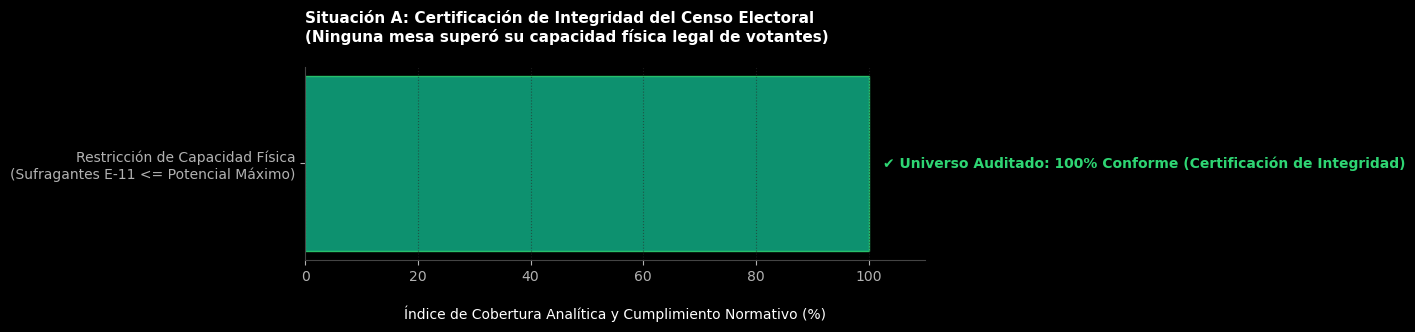

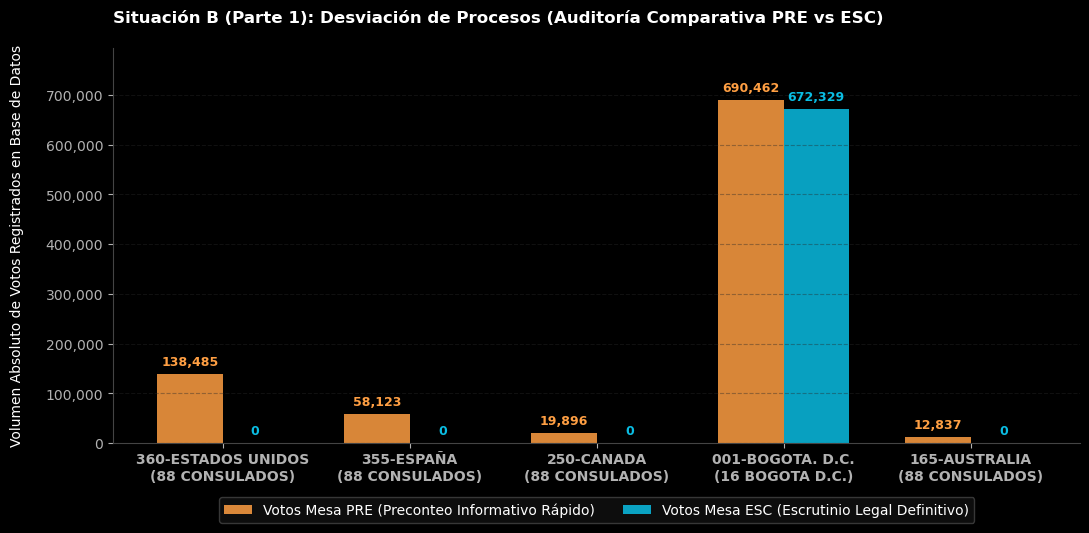

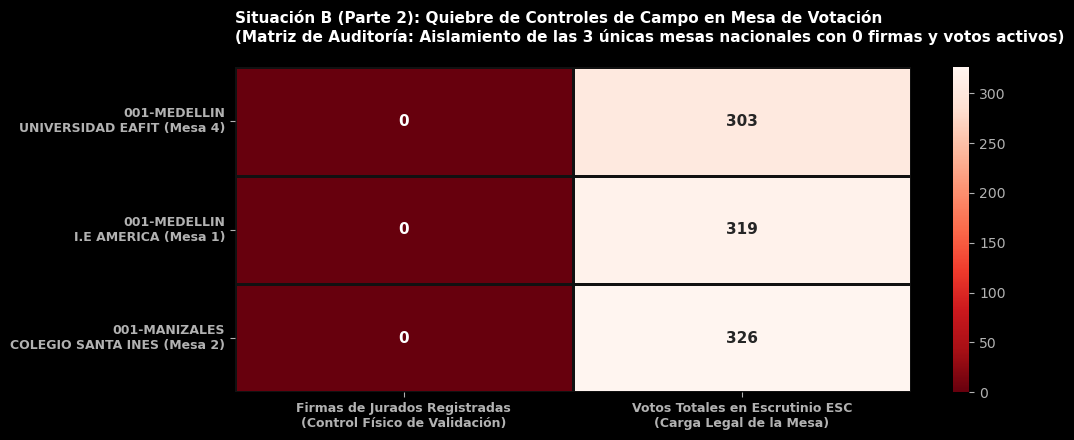

In [7]:
import sys
import os
import pandas as pd

# Asegurar la ruta raíz del proyecto
sys.path.append(os.path.abspath(os.path.join('.')))

# Importar las funciones analíticas actualizadas
from src.utils_plots import graficar_situacion_a_censo, graficar_situacion_b_desviacion, graficar_situacion_b_alertas

graficar_situacion_a_censo(total_mesas_analizadas)
print("\n" + "="*90 + "\n")

graficar_situacion_b_desviacion(top_5_variabilidad)
print("\n" + "="*90 + "\n")

# Esta llamará al nuevo Heatmap adaptativo usando 'Votos Mesa ESC'
graficar_situacion_b_alertas(mesas_criticas)

## **Fase 6: Actuar – De la Evidencia a la Decisión**

Esta fase marca la transición clave entre el análisis técnico y el ejercicio del control institucional. Si bien el rol del auditor analítico (analista de datos) 
culmina con la entrega de evidencia, estos hallazgos demandan una intervención por parte de la Alta Dirección
y las autoridades competentes. Los datos ya hablaron y aislaron las anomalías; ahora corresponde transformar esa inteligencia en decisiones 
vinculantes.